In [11]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
os.chdir('..')

In [10]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

In [3]:
CAR_SHARE_PATH = "data/filtered_block_groups/car_share.geojson"
MODEL_DATA_PATH = "data/modeling/model_data.geojson"

In [5]:
car_share = gpd.read_file(CAR_SHARE_PATH)

In [21]:
car_share.head()

,geo_id,total_trips,car_trips,land_area,water_area,geometry
0,1500000US040131141001,1025.0,671.0,1309884,0,"POLYGON ((-1477964.783 1279049.196, -1477524.6..."
1,1500000US060750117001,222.0,0.0,58882,0,"POLYGON ((-2273903.153 1957521.268, -2273629.6..."
2,1500000US080310026031,746.0,242.0,154515,0,"POLYGON ((-762077.536 1894730.32, -761912.815 ..."
3,1500000US080410016002,1164.0,487.0,1055779,9954,"POLYGON ((-758252.613 1793440.502, -758025.711..."
4,1500000US091703614012,340.0,46.0,72671,0,"POLYGON ((1897480.148 2265173.773, 1897554.338..."


In [22]:
car_share["car_trip_share"] = car_share["car_trips"] / car_share["total_trips"]

In [6]:
model_data = gpd.read_file(MODEL_DATA_PATH)

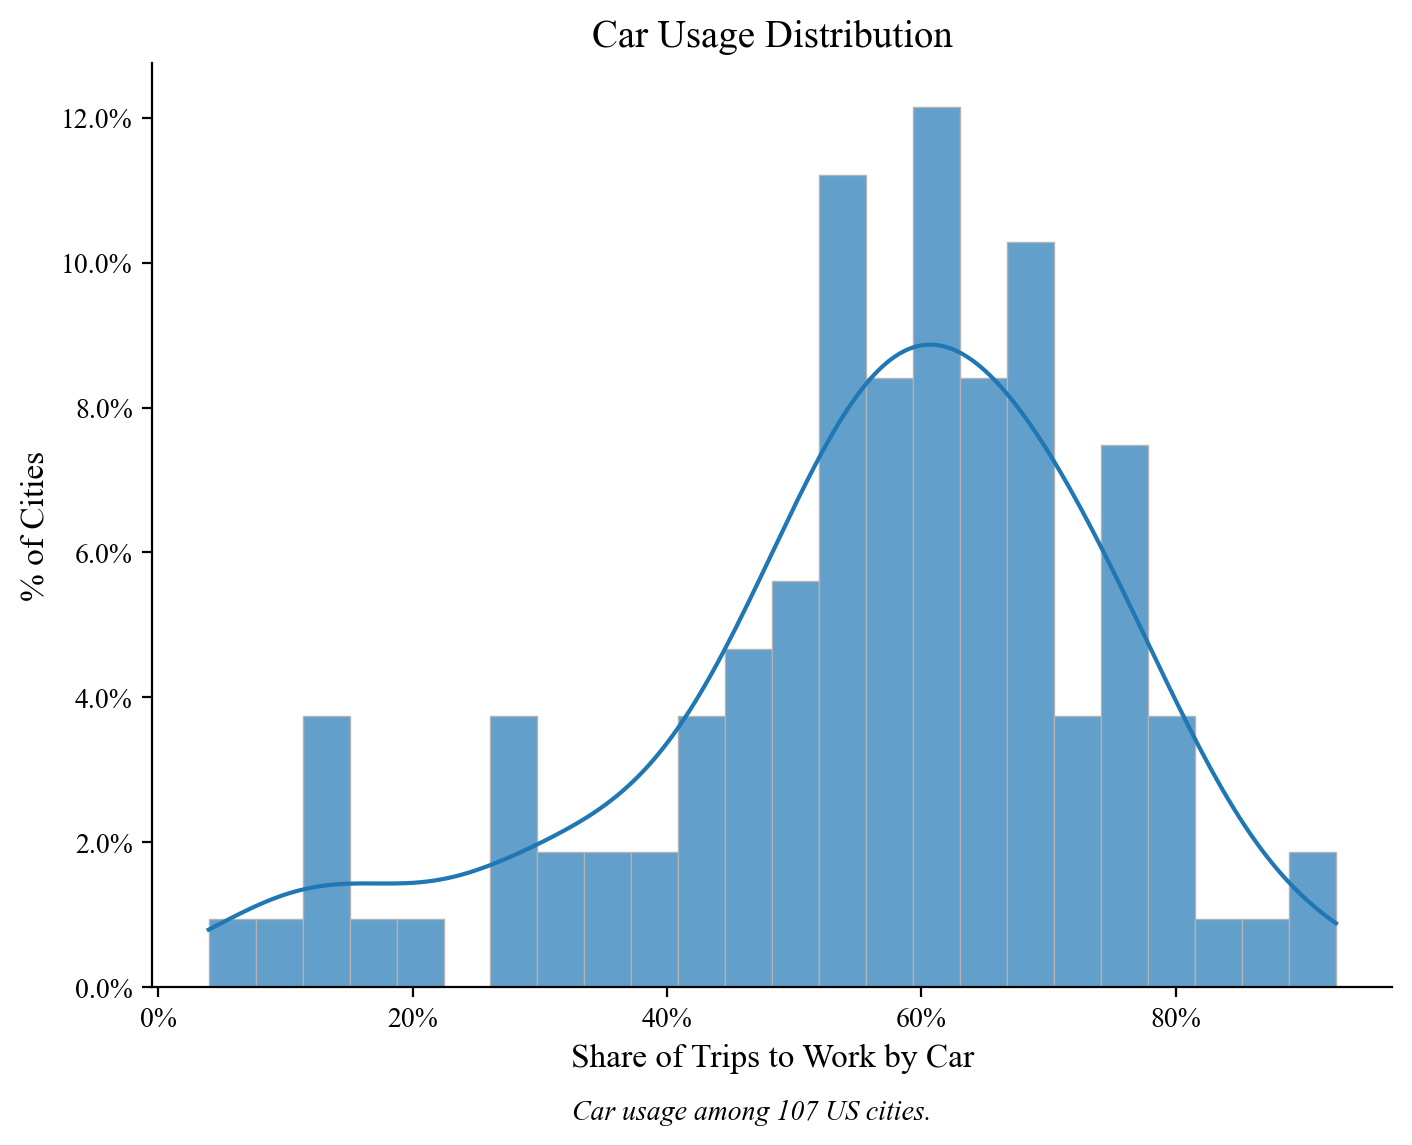

In [20]:
fig, ax = plt.subplots(figsize=(8,6), dpi=200)

ax = sns.histplot(
    model_data["car_trip_share"],
    bins=24,
    kde=True,
    alpha=0.7,
    linewidth=0.5,
    edgecolor="0.7",
    stat="percent" 
)

sns.despine(ax=ax, top=True, right=True)

ax.set_title("Car Usage Distribution")
ax.set_xlabel("Share of Trips to Work by Car")
ax.set_ylabel("% of Cities")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

fig.text(
        0.5, 0.0, 
        "Car usage among 107 US cities.",
        ha="center", 
        fontsize=10, 
        style='italic',
        wrap=True
    )

plt.show()

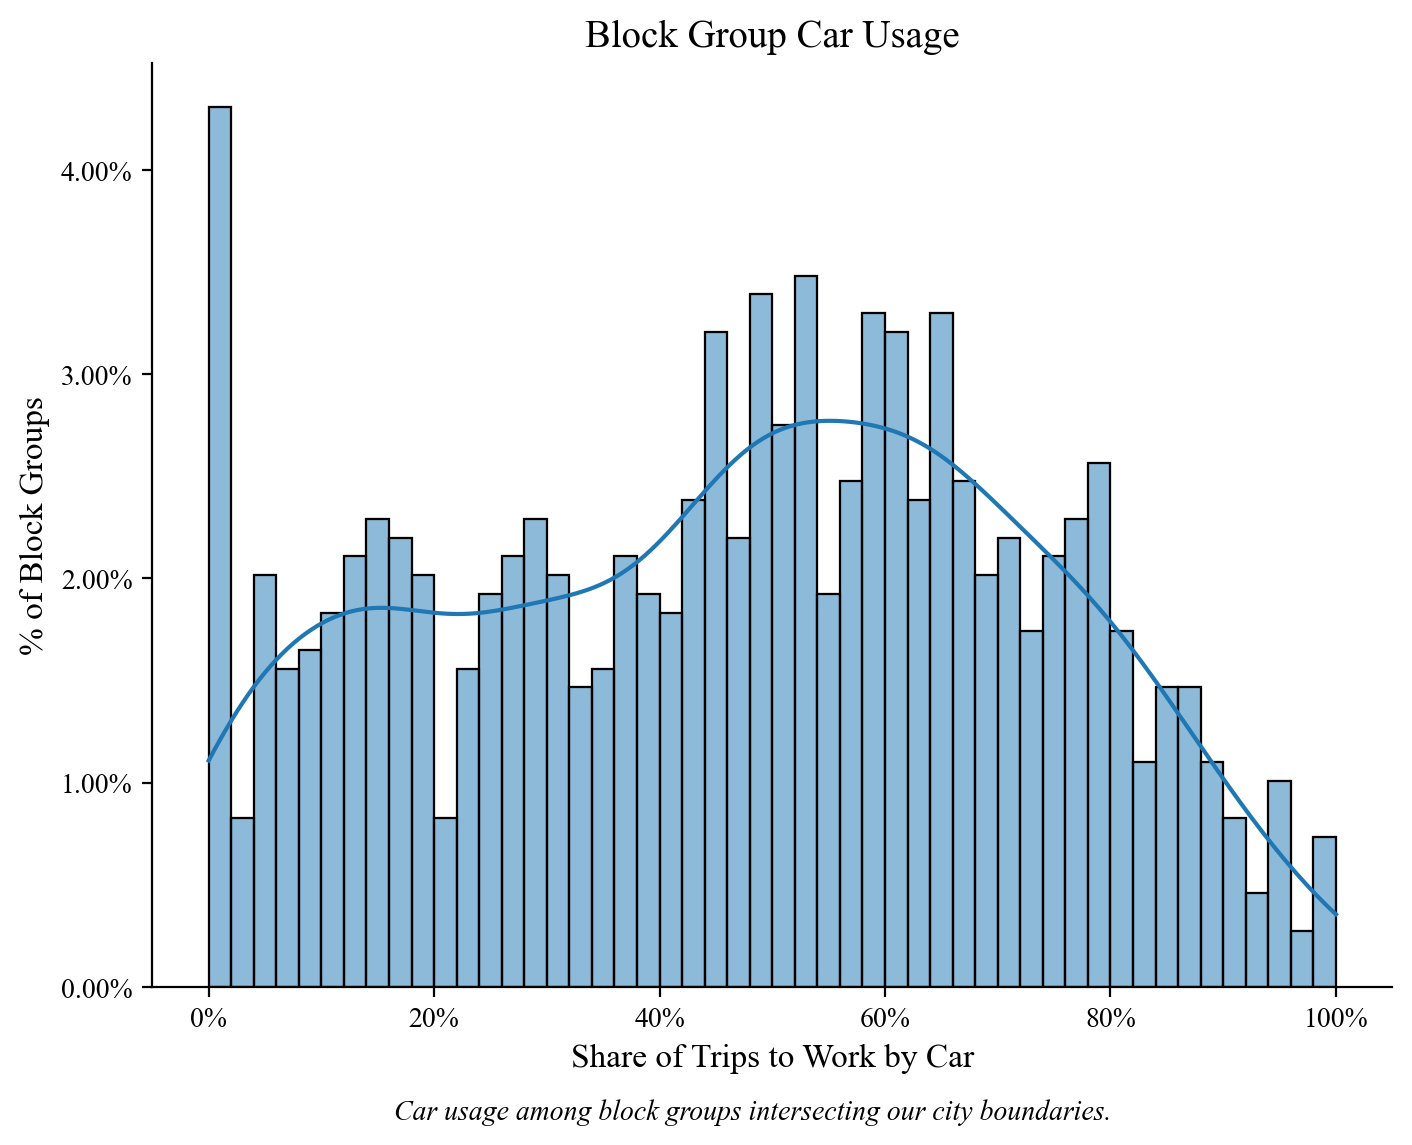

In [27]:
fig, ax = plt.subplots(figsize=(8,6), dpi=200)

ax = sns.histplot(
    car_share["car_trip_share"],
    bins=50,
    kde=True,
    stat="percent" 
)

sns.despine(ax=ax, top=True, right=True)

ax.set_title("Block Group Car Usage")
ax.set_xlabel("Share of Trips to Work by Car")
ax.set_ylabel("% of Block Groups")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

fig.text(
        0.5, 0.0, 
        "Car usage among block groups intersecting our city boundaries.",
        ha="center", 
        fontsize=10, 
        style='italic',
        wrap=True
    )

plt.show()